# 10 - Pixel-space generative prior (score-based DA)

An unconditional diffusion model trained on the LOVECLIM anomaly fields replaces
the Gaussian background of 3DVar. Reconstruction is guided posterior sampling: the
EDM reverse process plus an observation-guidance score
`grad log p(y | x_sigma) = -0.5 (y - H x_hat)^T V^-1 (y - H x_hat)`, with
`V = R + gamma b sigma^2 / (b + sigma^2)` for `b` the prior variance at the
observed cell, and `x_hat = D(x_sigma; sigma)` (Manshausen et al. 2025;
Rozet and Louppe 2023; Chung et al. 2023).

Two priors mirror the compressors: the older chronological half for the same-model
PPE lane, all ages for the withholding lane. `LANES` selects which of the two run,
and the priors to train follow from it. `gamma` (the trust multiplier on that
prior-variance term, 1 by the Gaussian derivation) is the tuned operating point,
selected on the held-out split and reported on the test split, so results land in
`outputs/da/generative/` on the same schema notebook 09 compares.

In [1]:
%load_ext autoreload
%autoreload 2

import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_v] = "1"

import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

sys.path.insert(0, os.path.abspath(".."))

from paleoreco.data import build_prior_cube, VARS
from paleoreco.data.cube import apply_anomaly, compute_zscore_stats
from paleoreco.data.splits import chronological_half_split
from paleoreco.assim.observations import (
    attach_site_stats, collapse_to_samples, load_observations, observation_site_stats,
)
from paleoreco.models.diffusion import CircularUNet, EDMDenoiser, load_denoiser, SIGMA_DATA
from paleoreco.training import trainer_diffusion as td
from paleoreco.assim.generative import GuidedSampler, cell_scales
from paleoreco.assim.sampler_pool import SamplerPool
from paleoreco.assim import experiments_generative as gex
from paleoreco.eval import da

plt.rcParams["figure.dpi"] = 110
DATA = "../data"
OUT = Path("../outputs/da")
CKPT = Path("../outputs/checkpoints/10_generative_prior")
FIG = Path("../outputs/figures/10_generative_prior")
CKPT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")

# Which lanes to run. The priors to train follow from the choice, so an
# inconsistent pair cannot be expressed.
LANES = ("ppe",)                        # subset of ("ppe", "withholding")
TRUTH_STRIDE = 10                       # ppe lane
FOLD_KIND, AGE_STRIDE = "random", 6     # withholding lane

LANE_PRIOR = {"ppe": "chunkA", "withholding": "full"}
LANE_NAME = {"ppe": "ppe", "withholding": f"withholding_{FOLD_KIND}"}
PRIORS = sorted({LANE_PRIOR[lane] for lane in LANES})
print("device:", DEVICE, "| lanes:", LANES, "| priors:", PRIORS)

/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda | lanes: ('ppe',) | priors: ['chunkA']


## Prior cube, chronological split, and the normalised anomaly frames

Each frame is the per-cell anomaly over its own ages, rescaled **per cell** to std
`SIGMA_DATA`, the scale the EDM recipe expects. The states, the climatology and the
scale field all come from those ages, so the PPE prior never sees the younger truths.

Scaling per cell rather than per channel leaves unit variance everywhere, so the
network learns correlation structure and the spatial variance pattern is carried by
the scale field instead. Two consequences follow and are worth holding in view when
reading the results below. The prior's variance geography is imposed rather than
learned, so its marginal per-cell variances come from the same empirical source
`diag(B)` does. And the network spends equal capacity on climatically inert cells and
on the North Atlantic centre carrying the D-O signal, which may cost skill even where
it helps calibration.

In [2]:
P = build_prior_cube(prior_csv=f"{DATA}/Prior.csv", cache_path=f"{DATA}/cache/prior_cube.npz")
cube, ages, lats, lons, valid = P["cube"], P["ages"], P["lats"], P["lons"], P["valid"]

all_idx = np.arange(len(ages))
prior_idx, truth_idx = chronological_half_split(ages, stride=TRUTH_STRIDE)
PRIOR_IDX = {"chunkA": prior_idx, "full": all_idx}

long_ppe = load_observations(f"{DATA}/Observation.csv")
long_wh = attach_site_stats(long_ppe, observation_site_stats(collapse_to_samples(long_ppe)))


def frame(idx):
    """safe_valid mask, per-cell scale field, and the SIGMA_DATA-scaled anomaly cube over ``idx``.

    The cube is restricted to ``idx`` after centring, so the states, the climatology
    and the scale field all come from the same ages.
    """
    stats = compute_zscore_stats(cube, idx, valid)
    anom = apply_anomaly(cube, stats)[idx]
    scales = cell_scales(anom, stats["safe_valid"])
    norm = anom * (SIGMA_DATA / scales)
    return stats["safe_valid"], scales, anom.astype(np.float64), norm.astype(np.float32)


FRAME = {name: frame(PRIOR_IDX[name]) for name in PRIORS}
print("cube", cube.shape, "| sites", long_ppe["site"].nunique())
for name, (safe, scales, _, norm) in FRAME.items():
    print(f"{name}: {norm.shape[0]} states | per-cell scale "
          f"{scales[:, safe].min():.3f} to {scales[:, safe].max():.3f} degC "
          f"| normalised per-cell std {norm[:, :, safe].std(axis=0).mean():.3f} "
          f"(target {SIGMA_DATA})")

cube (804, 2, 32, 64) | sites 187
chunkA: 402 states | per-cell scale 0.092 to 6.839 degC | normalised per-cell std 0.500 (target 0.5)


## Train the diffusion priors

Small U-Net, EDM denoising-score-matching with EMA. Data is scarce (hundreds of
autocorrelated states), so the epoch count is selected rather than fixed: each prior
first *searches* on a random 75/25 split, stopping once the held-out score has not
improved for `PATIENCE` epochs, then *refits* on every state up to the best epoch.

The held-out score is the EDM loss on a fixed grid of noise levels with fixed noise,
not the training loss: the training loss draws a random noise level per sample, and
that spread is far larger than the epoch-to-epoch change early stopping has to
resolve. It scores the EMA weights, since those are what the checkpoint saves and
the sampler loads.

The refit keeps the cosine horizon at `EPOCHS`, so it follows the same learning-rate
trajectory the search selected on and the chosen epoch keeps its meaning. Set
`RETRAIN = False` once the checkpoints exist to skip both phases; a checkpoint left
over from a different scale frame is retrained regardless, since its weights are not
usable in this one.

In [3]:
RETRAIN = False
EPOCHS, BASE, DEPTH, LR, BATCH = 3000, 64, 2, 2e-4, 64
VAL_FRACTION, PATIENCE, SPLIT_SEED = 0.25, 50, 0
T0 = time.time()


def _net():
    return EDMDenoiser(CircularUNet(base_channels=BASE, depth=DEPTH,
                                    grid_shape=tuple(cube.shape[2:])))


def checkpoint_path(name):
    return CKPT / f"diffusion_{name}.pt"


def _frame_matches(path, shape):
    """Whether a checkpoint was trained in the scale frame about to be used.

    A checkpoint from a different frame would otherwise be kept and then fail when
    the sampler loads it, so a stale one is retrained rather than skipped.
    """
    try:
        return np.shape(torch.load(path, map_location="cpu").get("scales")) == shape
    except Exception:
        return False


def train_prior(name):
    """Select the epoch count on a held-out split, then refit on every state."""
    safe, scales, _, norm = FRAME[name]
    path = checkpoint_path(name)
    if path.exists() and not RETRAIN and _frame_matches(path, scales.shape):
        print("exists:", path.name)
        return None

    perm = np.random.default_rng(SPLIT_SEED).permutation(len(norm))
    n_val = int(round(VAL_FRACTION * len(norm)))
    val_idx, train_idx = perm[:n_val], perm[n_val:]

    print(f"[{name}] search | {len(train_idx)} train / {len(val_idx)} val "
          f"| max {EPOCHS} ep, patience {PATIENCE}", flush=True)
    t = time.time()
    search = td.train(_net(), norm[train_idx], safe, val_cube=norm[val_idx],
                      patience=PATIENCE, max_epochs=EPOCHS, batch_size=BATCH,
                      lr=LR, device=DEVICE, seed=0)
    n_star = search["best_epoch"] + 1          # 0-based index -> epoch count
    print(f"[{name}] search | done in {time.time() - t:.0f}s "
          f"| best ep {search['best_epoch']} | stopped at {search['stop_epoch']} "
          f"| early={search['stopped_early']} | refit to {n_star}", flush=True)

    print(f"[{name}] refit | {n_star} ep on {len(norm)} states", flush=True)
    t = time.time()
    td.train(_net(), norm, safe, max_epochs=n_star, lr_schedule_epochs=EPOCHS,
             batch_size=BATCH, lr=LR, device=DEVICE, checkpoint_path=str(path),
             scales=scales, seed=0,
             checkpoint_extra={"selection": {
                 "best_epoch": int(search["best_epoch"]),
                 "stop_epoch": int(search["stop_epoch"]),
                 "refit_epochs": int(n_star),
                 "stopped_early": bool(search["stopped_early"]),
                 "patience": int(PATIENCE), "val_fraction": float(VAL_FRACTION),
                 "split_seed": int(SPLIT_SEED), "max_epochs": int(EPOCHS)}})
    print(f"[{name}] refit | done in {time.time() - t:.0f}s | wrote {path.name}", flush=True)

    np.savez(CKPT / f"{path.stem}_search.npz",
             **{k: np.asarray(v) for k, v in search["history"].items()})
    return search


SEARCH = {name: train_prior(name) for name in PRIORS}
print(f"total {time.time() - T0:.0f}s")

[chunkA] search | 302 train / 100 val | max 3000 ep, patience 50


diffusion:   0%|          | 0/3000 [00:00<?, ?ep/s]

diffusion:   0%|          | 0/3000 [00:01<?, ?ep/s, loss=1.0491, val=0.8950, best=0.8950, wait=0, s/ep=1.6]

diffusion:   0%|          | 1/3000 [00:01<1:19:01,  1.58s/ep, loss=1.0491, val=0.8950, best=0.8950, wait=0, s/ep=1.6]

epoch    0  loss=1.0491  val=0.8950  best=0.8950@0  lr=2.00e-04  (1.6s)


...

diffusion: 100%|█████████▉| 1106/1107 [05:58<00:00,  2.11ep/s, loss=0.1309, s/ep=0.5]

diffusion: 100%|██████████| 1107/1107 [05:58<00:00,  2.11ep/s, loss=0.1337, s/ep=0.5]

diffusion: 100%|██████████| 1107/1107 [05:58<00:00,  3.09ep/s, loss=0.1337, s/ep=0.5]

[chunkA] refit | done in 359s | wrote diffusion_chunkA.pt


total 1236s


### Search curves

Red marks where early stopping halted the search, grey the best epoch the refit used.
On the left all three curves are the same fixed-grid score, so the gap between the
training probe and the held-out curve is the generalisation gap, and the gap between
the EMA and live curves is the lag introduced by weight averaging. The right panel is
the random-sigma quantity actually minimised, which sits on its own scale.

If the probe and held-out curves sit on top of each other and never separate, the
random split has no detection power on states this autocorrelated, and the result is
inconclusive rather than evidence of no overfitting.

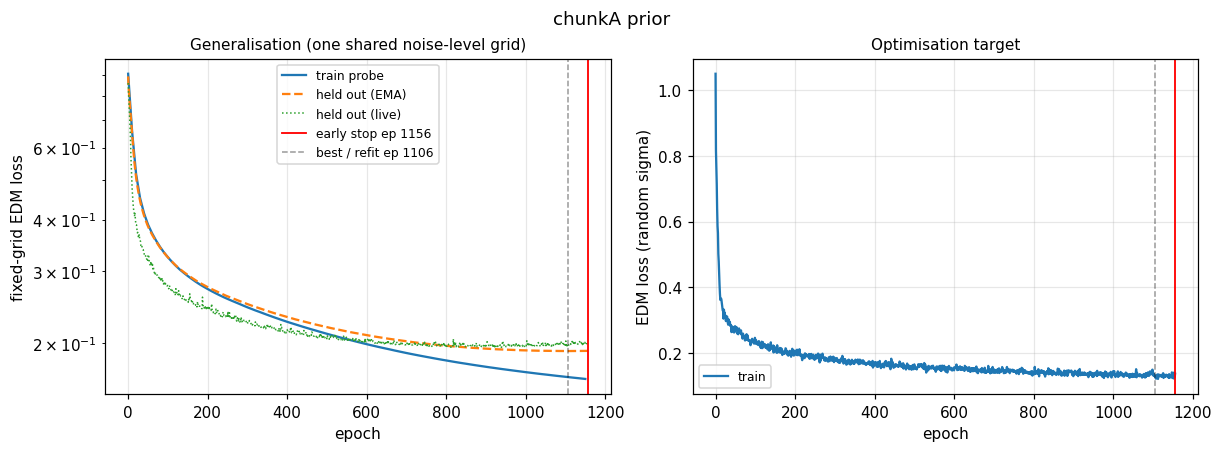

In [4]:
from paleoreco.eval.diffusion import plot_loss_curves_diffusion

for name, search in SEARCH.items():
    if search is None:
        continue
    plot_loss_curves_diffusion(
        search["history"], best_epoch=search["best_epoch"],
        stop_epoch=search["stop_epoch"] - 1, title=f"{name} prior",
        save_path=str(FIG / f"loss_curves_{name}.png"))
    plt.show()

## Build the samplers

One sampler per trained prior for the diagnostics below. The lanes themselves run on
a `SamplerPool`, built and closed around each lane: a single posterior draw occupies
a fraction of the GPU, so spreading independent draws over `N_WORKERS` processes is
most of the run's wall clock. Every draw carries its own seed, so the pooled result
is the serial one.

Each sampler and pool also takes its own prior's per-cell variance, the `b` the
guidance covariance anneals toward. It is estimated from unconditional draws of the
same checkpoint, so the likelihood and the prior hold one belief, and the PPE lane's
guidance never sees the younger truths. In the per-cell frame those draws carry unit
variance in the normalised space, so `b` lands near the scale field squared; sampling
it rather than imposing it keeps any departure visible.

Ensemble sizes are asymmetric. Below about 16 members a draw costs what one member
costs, so `K_SELECT` is free; the reported `K` is larger because averaging a finite
ensemble inflates the error by `mean(post_var) / K`, and 3DVar carries no such term.

In [5]:
N_STEPS, N_CORRECT, TAU = 64, 2, 0.3
GAMMA_GRID = gex.GAMMA_GRID
K, K_SELECT = 32, 16
N_WORKERS = 2
N_PRIOR_VAR = 512
SAMPLER_KW = dict(n_samples=K, n_steps=N_STEPS, n_correct=N_CORRECT,
                  corrector_tau=TAU, device=DEVICE)


def load_sampler(name, prior_var):
    net, scales = load_denoiser(str(checkpoint_path(name)))
    return GuidedSampler(net, np.asarray(scales), FRAME[name][0], prior_var, **SAMPLER_KW)


def prior_var_map(name, n=N_PRIOR_VAR, seed=0):
    """Per-cell prior variance from ``n`` unconditional draws, anomaly units.

    An unconditional draw never evaluates the likelihood, so the placeholder the
    drawing sampler is built with cannot reach the result. Batched because an
    ensemble this size does not fit in one forward pass.
    """
    safe = FRAME[name][0]
    s = load_sampler(name, np.zeros((len(VARS), *safe.shape)))
    ens = np.concatenate([s.sample_prior(64, seed=seed + k) for k in range(n // 64)])
    return ens.var(axis=0, ddof=1)


PRIOR_VAR = {name: prior_var_map(name) for name in PRIORS}
SAMPLER = {name: load_sampler(name, PRIOR_VAR[name]) for name in PRIORS}

for name in PRIORS:
    safe, scales, _, _ = FRAME[name]
    pv = PRIOR_VAR[name][:, safe]
    print(f"{name}: prior std {np.sqrt(pv).mean():.3f} degC against a scale field of "
          f"{scales[:, safe].mean():.3f} | corr "
          f"{np.corrcoef(np.sqrt(pv).ravel(), scales[:, safe].ravel())[0, 1]:.3f}")

chunkA: prior std 0.772 degC against a scale field of 0.819 | corr 0.999


## Unconditional sanity: did the prior learn the climate?

Given the small training set, check that generated fields resemble real LOVECLIM
states (per-cell std, leading-PC score spread) and that the model is not
regurgitating training snapshots (nearest-neighbour distance).

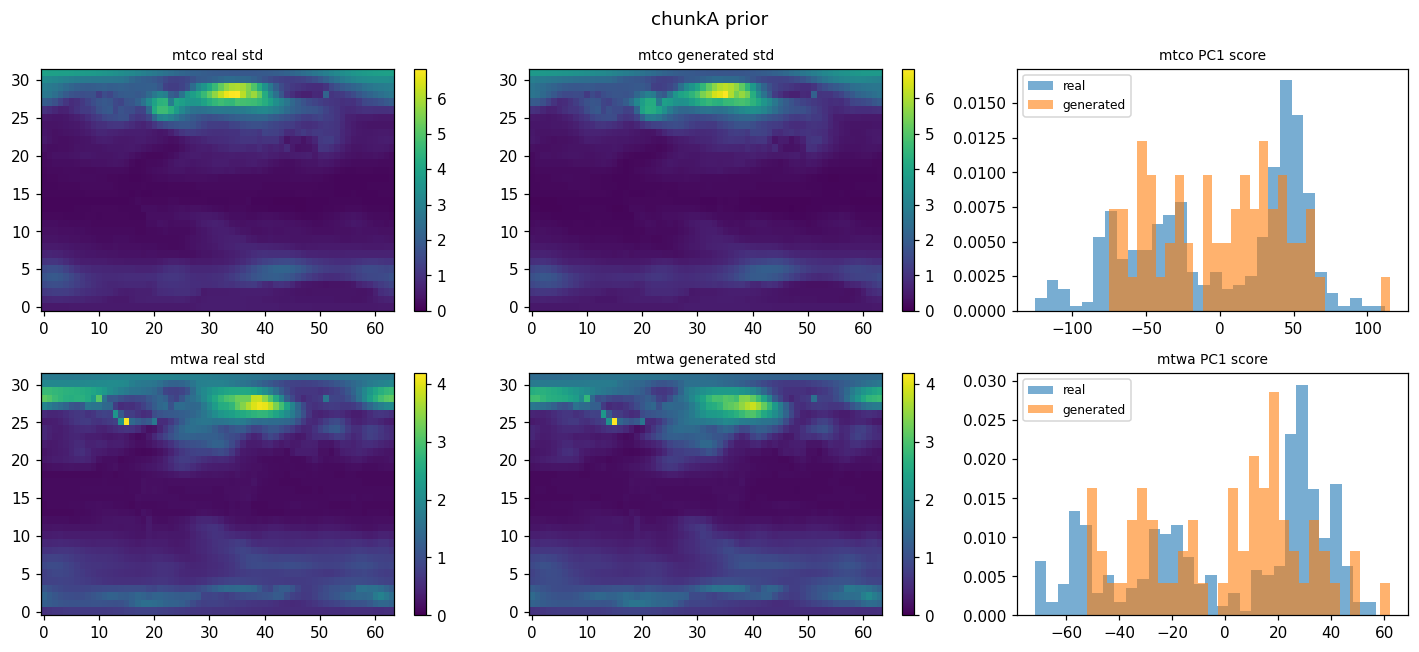

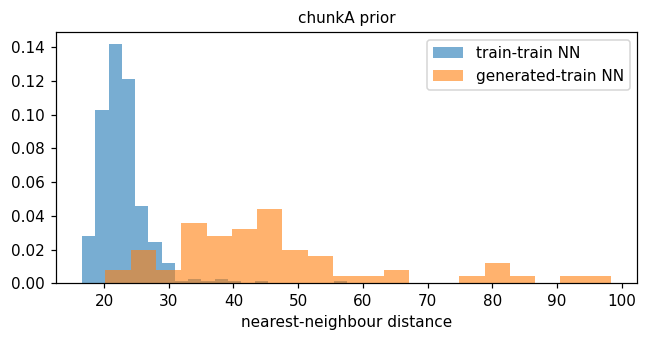

chunkA: median NN distance generated 43.040 | train 22.226


In [6]:
from scipy.spatial.distance import cdist

for name in PRIORS:
    safe, _, anom, _ = FRAME[name]
    real = anom[:, :, safe]
    gen = SAMPLER[name].sample_prior(64, seed=0)[:, :, safe]

    fig, axes = plt.subplots(2, 3, figsize=(13, 6))
    for c, ch in enumerate(VARS):
        vmax = float(real[:, c].std(0).max())
        for col, (title, field) in enumerate((("real std", real[:, c].std(0)),
                                              ("generated std", gen[:, c].std(0)))):
            m = np.full(safe.shape, np.nan); m[safe] = field
            ax = axes[c, col]
            im = ax.imshow(m, origin="lower", cmap="viridis", vmin=0, vmax=vmax,
                           aspect="auto")
            ax.set_title(f"{ch} {title}", fontsize=9)
            fig.colorbar(im, ax=ax, fraction=0.046)
        # leading-PC score distribution, generated vs real
        Xr = real[:, c] - real[:, c].mean(0)
        pc = np.linalg.svd(Xr, full_matrices=False)[2][0]
        axes[c, 2].hist(Xr @ pc, bins=30, density=True, alpha=0.6, label="real")
        axes[c, 2].hist((gen[:, c] - real[:, c].mean(0)) @ pc, bins=30, density=True,
                        alpha=0.6, label="generated")
        axes[c, 2].set_title(f"{ch} PC1 score", fontsize=9)
        axes[c, 2].legend(fontsize=8)
    fig.suptitle(f"{name} prior")
    fig.tight_layout()
    fig.savefig(FIG / f"unconditional_quality_{name}.png", bbox_inches="tight")
    plt.show()

    # Memorisation: nearest training state per generated sample against a train-train
    # baseline. cdist avoids the O(N^2 D) broadcast that would materialise tens of GB.
    gv, rv = gen.reshape(len(gen), -1), real.reshape(len(real), -1)
    d_gen = cdist(gv, rv).min(1)
    dd = cdist(rv, rv); np.fill_diagonal(dd, np.inf)
    d_train = dd.min(1)
    fig, ax = plt.subplots(figsize=(6, 3.2))
    ax.hist(d_train, bins=20, density=True, alpha=0.6, label="train-train NN")
    ax.hist(d_gen, bins=20, density=True, alpha=0.6, label="generated-train NN")
    ax.set_xlabel("nearest-neighbour distance"); ax.legend()
    ax.set_title(f"{name} prior", fontsize=10)
    fig.tight_layout(); fig.savefig(FIG / f"memorisation_{name}.png", bbox_inches="tight")
    plt.show()
    print(f"{name}: median NN distance generated {np.median(d_gen):.3f} "
          f"| train {np.median(d_train):.3f}")

## Run the generative lanes

PPE on the older-half prior, withholding on the all-ages prior, whichever `LANES`
selects. `gamma` is swept on the selection split and reported at its winner on the
test split; withholding is age-subsampled for cost (the stride is recorded in the
config). Results share the `outputs/da/generative/` schema, so notebook 09 compares
them against 3DVar.

Each lane clears only its own rows and files before running, so one lane can be run
now and the other added later without disturbing it. Each opens its own pool and
closes it before the next, so only one set of workers holds GPU memory at a time.
`progress_every` counts posterior draws, and the ETA covers a whole pass, so each
lane prints a selection block and a test block.

In [7]:
d = OUT / "generative"
t_lanes = time.time()

for lane in LANES:
    prior = LANE_PRIOR[lane]
    gex.clear_lane(str(d), LANE_NAME[lane])
    print(f"[{lane}] on the {prior} prior", flush=True)
    with SamplerPool(str(checkpoint_path(prior)), FRAME[prior][0], PRIOR_VAR[prior],
                     n_workers=N_WORKERS, **SAMPLER_KW) as pool:
        if lane == "ppe":
            gex.run_ppe_generative(
                cube, ages, lats, lons, valid, long_ppe, str(d), sampler=pool,
                gamma_grid=GAMMA_GRID, n_samples=K, n_samples_select=K_SELECT,
                truth_stride=TRUTH_STRIDE, progress_every=25)
        else:
            gex.run_withholding_generative(
                cube, ages, lats, lons, valid, long_wh, str(d), sampler=pool,
                gamma_grid=GAMMA_GRID, n_samples=K, n_samples_select=K_SELECT,
                fold_kind=FOLD_KIND, age_stride=AGE_STRIDE, progress_every=100)

print(f"{len(LANES)} lane(s) in {time.time() - t_lanes:.0f}s")
print("wrote", sorted(p.name for p in d.iterdir()))

[ppe] on the chunkA prior


  ppe selection draws 25/240 (10%, elapsed 63s, eta 545s)


  ppe selection draws 50/240 (21%, elapsed 116s, eta 440s)


  ppe selection draws 75/240 (31%, elapsed 173s, eta 380s)


  ppe selection draws 100/240 (42%, elapsed 225s, eta 315s)


...

  ppe selection draws 175/240 (73%, elapsed 391s, eta 145s)


  ppe selection draws 200/240 (83%, elapsed 443s, eta 89s)


  ppe selection draws 225/240 (94%, elapsed 500s, eta 33s)


  ppe test draws 25/41 (61%, elapsed 119s, eta 76s)


1 lane(s) in 726s
wrote ['metrics.csv', 'ppe_analysis.npz', 'ppe_config.json']


## Prior vs posterior

The gamma tuning curve, the prior-to-posterior variance reduction (reused from the
3DVar diagnostic), and the pointwise prior/posterior distribution at a cell near a
site and one far from any site.

The tuning curve plots `rrmse_ens`, the surface `gamma` was actually selected on:
plain RRMSE carries the finite-ensemble term `mean(post_var) / K`, which grows with
`gamma` and so tilts the curve toward the small end.

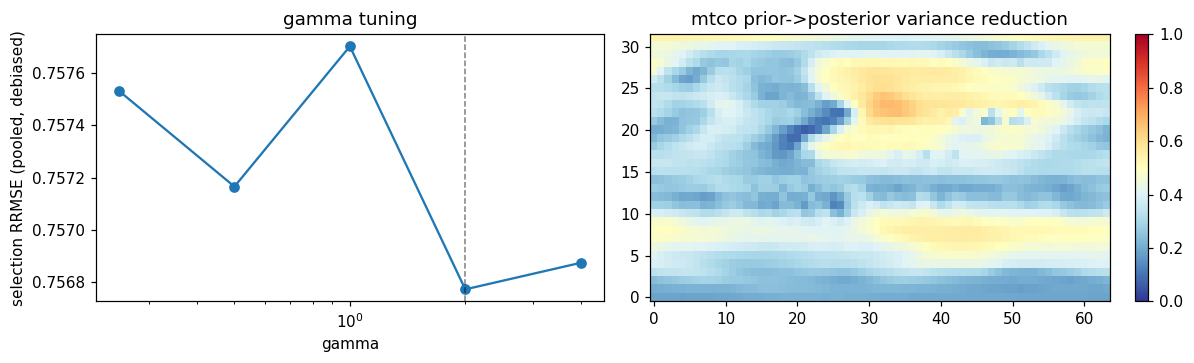

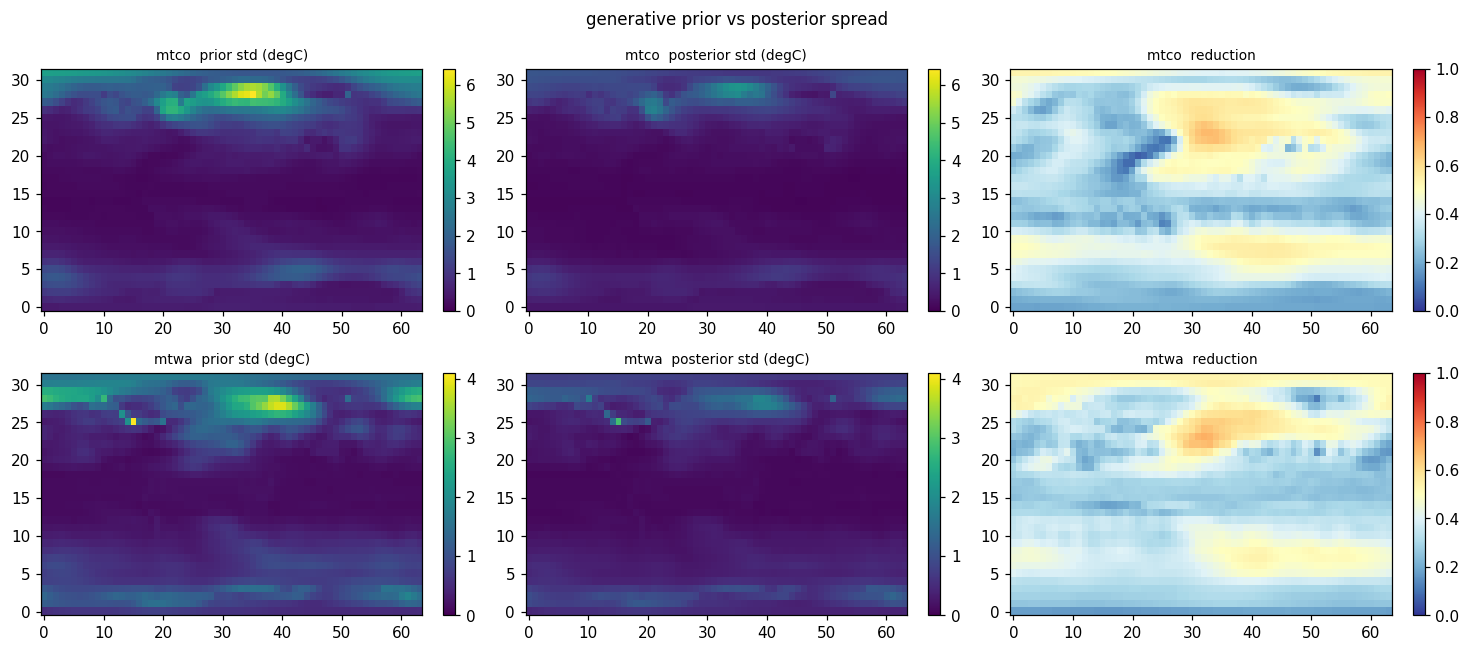

In [8]:
if "ppe" in LANES:
    M = pd.read_csv(OUT / "generative" / "metrics.csv")
    sel = M[(M.lane == "ppe") & (M.split == "selection") & (M.channel == "pooled")
            & (M.do_event == "all") & (M.metric == "rrmse_ens")].sort_values("b_scale")

    z = np.load(OUT / "generative" / "ppe_analysis.npz")
    safe_ppe = z["safe_valid"]
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
    ax[0].plot(sel["b_scale"], sel["value"], "o-"); ax[0].set_xscale("log")
    ax[0].axvline(float(z["b_scales"][0]), color="k", lw=1, ls="--", alpha=0.5)
    ax[0].set_xlabel("gamma"); ax[0].set_ylabel("selection RRMSE (pooled, debiased)")
    ax[0].set_title("gamma tuning")

    red = da.uncertainty_reduction(z["prior_ens_var"], z["post_var"][0].mean(axis=0))
    im = ax[1].imshow(np.where(safe_ppe, red[0], np.nan), origin="lower", cmap="RdYlBu_r",
                      vmin=0, vmax=1, aspect="auto")
    ax[1].set_title("mtco prior->posterior variance reduction")
    fig.colorbar(im, ax=ax[1], fraction=0.046)
    fig.tight_layout()
    fig.savefig(FIG / "gamma_and_variance_reduction.png", bbox_inches="tight")
    plt.show()

    da.plot_prior_posterior_uncertainty(
        z["prior_ens_var"], z["post_var"][0].mean(axis=0), safe_ppe, VARS,
        title="generative prior vs posterior spread",
        save_path=str(FIG / "uncertainty_reduction_generative.png"))
    plt.show()

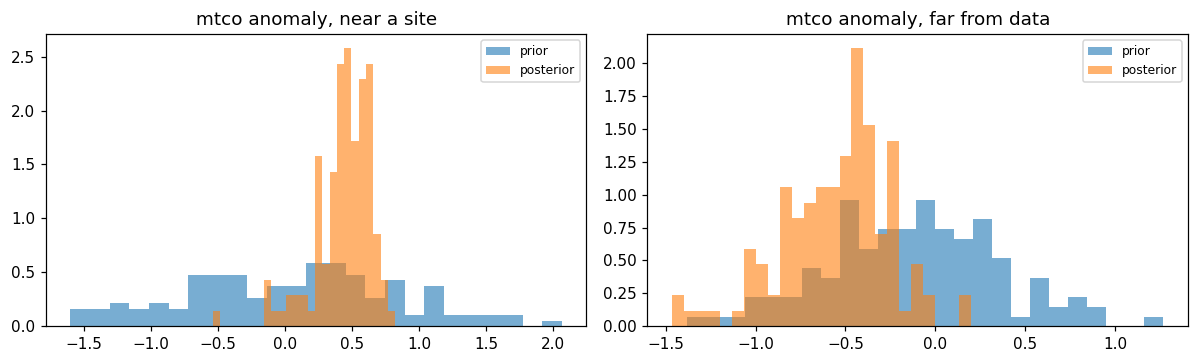

In [9]:
# Pointwise prior vs posterior at a near-site and a far cell (mtco), for one truth.
from paleoreco.assim.observations import observations_at_age
from paleoreco.assim.experiments import _obs_geometry

if "ppe" in LANES:
    samp = SAMPLER[LANE_PRIOR["ppe"]]
    n_cells = len(lats) * len(lons)
    safe_flat = np.broadcast_to(safe_ppe, (len(VARS), *safe_ppe.shape)).ravel()
    age0 = int(z["drawn_ages"][0, -1])
    geom = _obs_geometry(observations_at_age(long_ppe, age0), lats, lons, safe_flat)
    y0 = z["truth_anom"][0].ravel()[geom["gather"]]
    gamma_star = float(z["b_scales"][0])
    post = samp.sample_posterior(geom["gather"], y0, geom["sse"], gamma_star, 128, seed=1)
    prior = samp.sample_prior(128, seed=2)

    # Index the mtco channel (cells 0..n_cells-1) at an observed site and at the void.
    near = int(geom["gather"][0]) % n_cells
    far = int(np.argmax(da.nearest_obs_distance(lats, lons, geom["lat"], geom["lon"])))
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
    for a, (cell, label) in zip(ax, ((near, "near a site"), (far, "far from data"))):
        a.hist(prior.reshape(128, -1)[:, cell], bins=25, density=True, alpha=0.6,
               label="prior")
        a.hist(post.reshape(128, -1)[:, cell], bins=25, density=True, alpha=0.6,
               label="posterior")
        a.set_title(f"mtco anomaly, {label}"); a.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG / "pointwise_prior_posterior.png", bbox_inches="tight")
    plt.show()

## Reading

The cross-method comparison against 3DVar (skill, calibration, prior-to-posterior,
gallery) lives in `09_da_comparison`, which discovers `outputs/da/generative/`
automatically.

Two things to read first in the per-cell frame. The generated per-cell std map should
now track the real one in amplitude as well as pattern, since the scale field carries
it rather than the network. And the calibration rows in notebook 09 are where the
change should show up if it helps: an under-dispersed prior was the mechanism behind
the posterior's overconfidence.